In [1]:
from scripts.default_import import *
from scripts.plotting import *
from scripts.scenario_reduction import (
    Fast_Forward_Selection,
    get_zeta_metric,
)
from scripts.scenario_generation import (
    generate_time_series,
    combine_reduced_scenarios,
    create_portfolios,
    roulette_wheel_selection,
)

np.random.seed(1)

# Automatically generate random scenarios for antigen


## Input the data


In [78]:
N_YEARS = 10  # ! Number of years to generate
N_SCENARIOS = 500  # ! Number of scenarios to generate
Q_SIZE = 4  # ! Number of scenarios to keep in the fast forward selection
SCALED_PROB = 0.2
YEARS = np.arange(1, N_YEARS + 1)

## Generate the random time series

In [79]:
antigen_dict, antigen_demand_dict, antigen_reduction_dict = {}, {}, {}
dfs = []
baseline_demand = pd.read_excel(
    f"{Github_path}/DATA/demand/Base_demand_80_percent_scenario.xlsx", sheet_name="Demand", index_col=0
)
baseline_demand.reset_index(names="antigen", inplace=True)
# Round the numbers to the nearest hundred
baseline_demand[YEARS] = baseline_demand[YEARS].round(-2).astype(int)
# Convert the demand to a list
baseline_demand["demands"] = baseline_demand[YEARS].values.tolist()
baseline_demand.drop(YEARS, axis=1, inplace=True)
# Add the probability and demand_SID columns
baseline_demand["prob"] = 1 - SCALED_PROB
baseline_demand["demand_SID"] = 1

for antigen in ANTIGENS:
    print(f"Processing {antigen}...")
    # Read the demand for each antigen
    temp = pd.read_excel(
        f"{Github_path}/DATA/demand/antigen_CI_Random_generator.xlsx", sheet_name=antigen, nrows=N_YEARS
    )
    # Increase the index by 1 to match the years
    temp.index += 1

    # Store the demand for each antigen in a dictionary
    antigen_dict[antigen] = temp

    # Generate the demand for each antigen
    temp_demand = generate_time_series(temp, 500, mu_col="Average", std_col="sd", lower_col="Lower", upper_col="Upper")
    # Round the numbers to the nearest hundred
    temp_demand[YEARS] = temp_demand[YEARS].round(-2).astype(int)
    # Convert the demand to a list
    temp_demand["demands"] = temp_demand[YEARS].values.tolist()

    # Store the demand for each antigen in a dictionary
    antigen_demand_dict[antigen] = temp_demand

    # Perform scenario reduction using the fast forward selection
    scenarios_P = temp_demand[YEARS].to_numpy()
    probabilities_P = temp_demand["prob"].to_numpy()

    FFS = Fast_Forward_Selection(temp_demand, "demands", verbose_level=0)
    ffs_set, ffs_probs, ffs_s_dict = FFS.run(Q_SIZE)
    temp_ffs_df = FFS.construct_reduced_df()
    scenarios_Q = np.array(temp_ffs_df["demands"].tolist())
    probabilities_Q = temp_ffs_df["prob"].to_numpy()
    scaled_probabilities_Q = SCALED_PROB * probabilities_Q
    # Store the reduction for each antigen in a dictionary
    antigen_reduction_dict[antigen] = {
        "scenarios_P": scenarios_P,
        "probabilities_P": probabilities_P,
        "scenarios_Q": scenarios_Q,
        "probabilities_Q": probabilities_Q,
        "scaled_probabilities_Q": scaled_probabilities_Q,
    }
    temp_df = pd.DataFrame(
        {
            "antigen": antigen,
            "demands": temp_ffs_df["demands"],
            "prob": scaled_probabilities_Q,
        }
    )
    temp_df["demand_SID"] = np.arange(2, len(temp_df) + 2)
    dfs.append(temp_df)

antigen_demand_df = pd.concat(dfs, ignore_index=True)
# Combine the baseline demand with the antigen demand
antigen_demand_df = pd.concat([baseline_demand, antigen_demand_df], ignore_index=True)
# Sort the dataframe by antigen and demand_SID
antigen_demand_df.sort_values(by=["antigen", "demand_SID"], inplace=True)

joblib.dump(antigen_dict, f"data/antigen_dictionary.pkl")
joblib.dump(antigen_demand_dict, f"data/antigen_demand_dictionary.pkl")
joblib.dump(antigen_reduction_dict, f"data/antigen_reduction_dictionary.pkl")
joblib.dump(antigen_demand_df, f"data/antigen_demand_df_{Q_SIZE+1}_scenarios.pkl")
antigen_demand_df.to_excel(f"{Github_path}/DATA/demand/antigen_demand_80_20_{Q_SIZE+1}_scenarios.xlsx", index=False)
antigen_demand_df.to_csv(f"{Github_path}/DATA/demand/antigen_demand_80_20_{Q_SIZE+1}_scenarios.csv", index=False)

Processing Diphtheria...
Processing Pertussis...
Processing Polio...
Processing Tetanus...
Processing Rotavirus...
Processing PCV...
Processing Measles...
Processing Mumps...
Processing Rubella...
Processing Hepatitis_B...
Processing Hib...
Processing HPV...


In [69]:
antigen_demand_df

,antigen,demands,prob,demand_SID
3,Diphtheria,"[570550200, 619539900, 626455400, 594496900, 5...",0.8000,1
12,Diphtheria,"[670584900, 758083100, 874670100, 821555700, 9...",0.1252,2
13,Diphtheria,"[621033000, 670430900, 819995600, 737025000, 7...",0.0748,3
9,HPV,"[18988200, 18779800, 27460000, 72849500, 92670...",0.8000,1
34,HPV,"[28819800, 39092500, 41845900, 45761800, 56189...",0.1280,2
35,HPV,"[30125300, 34476600, 41559000, 44040200, 53552...",0.0720,3
6,Hepatitis_B,"[312284600, 343008200, 351717800, 334973600, 3...",0.8000,1
30,Hepatitis_B,"[368800300, 403154600, 382265600, 325120800, 3...",0.1344,2
31,Hepatitis_B,"[394753400, 365320900, 397379800, 350672200, 3...",0.0656,3
7,Hib,"[259536200, 282777100, 287252900, 274027900, 2...",0.8000,1


### Visualize all the demand data


Text(0.5, 1.02, 'Full 500 demand for each antigen over 10 years')

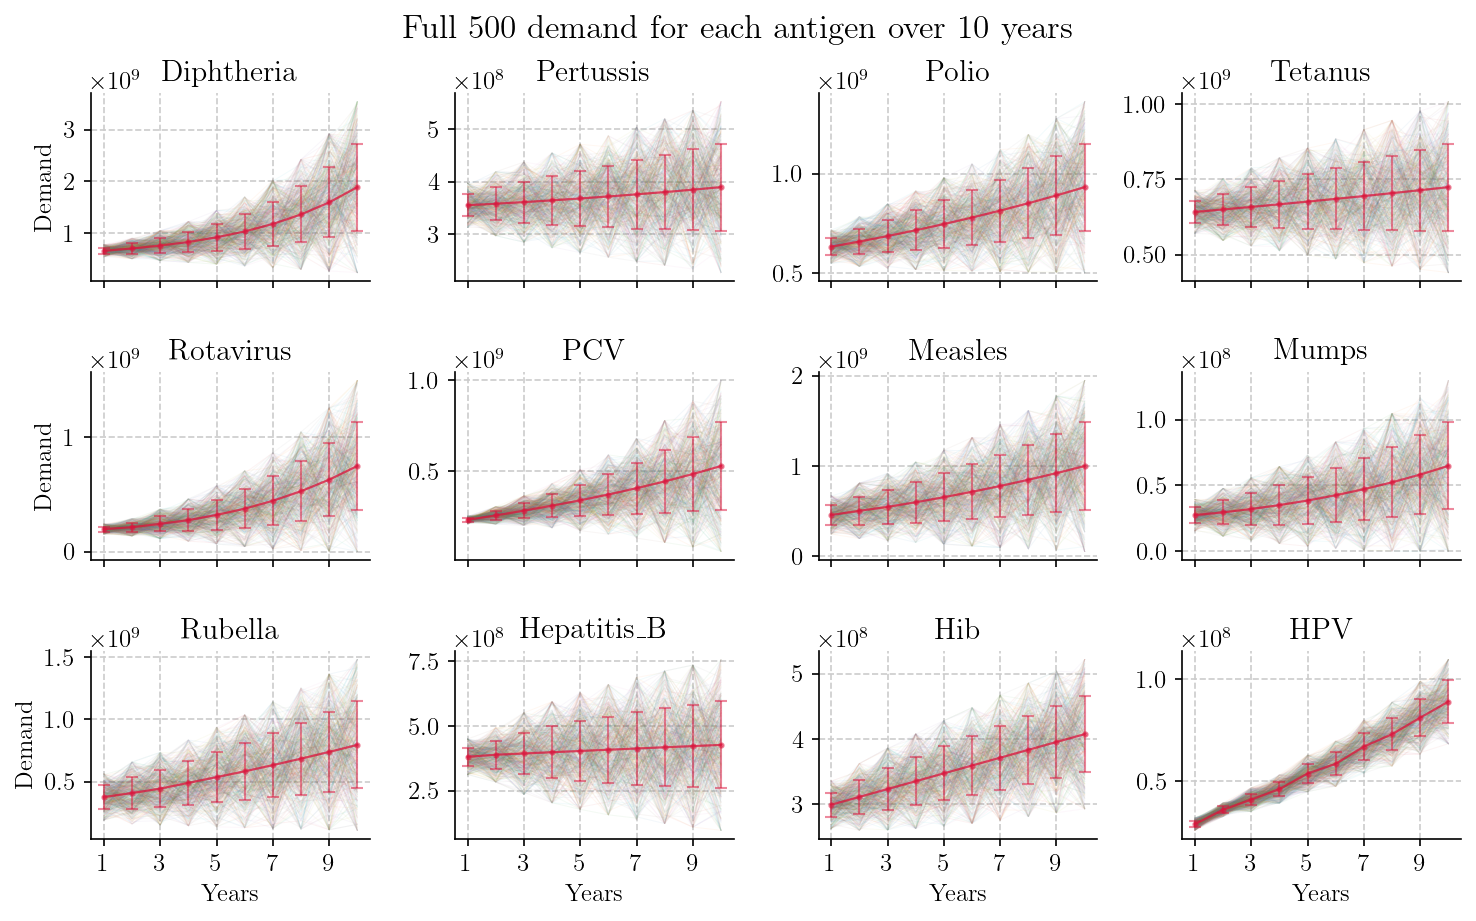

In [8]:
fig, axes = plt.subplots(figsize=(10, 6), ncols=4, nrows=3, sharex=True, sharey=False)
axes = axes.flatten()
for i, antigen in enumerate(ANTIGENS):
    ax = axes[i]
    temp = antigen_dict[antigen]
    temp_demand = antigen_demand_dict[antigen]
    # Plot the average and standard deviation of the demand
    ax.plot(YEARS, temp["Average"], lw=1, color="crimson", zorder=10, alpha=0.5)
    ax.errorbar(
        YEARS,
        temp["Average"],
        yerr=temp["sd"],
        fmt="-o",
        color="crimson",
        zorder=11,
        ms=2,
        lw=1,
        capsize=3,
        alpha=0.5,
    )

    # Plot the demand for each scenario
    for _, row in temp_demand.iterrows():
        ax.plot(YEARS, row[YEARS], lw=0.5, alpha=0.05)

    ax.set_title(antigen)
    add_grid(ax)

for i in [0, 4, 8]:
    axes[i].set_ylabel("Demand")
for i in [8, 9, 10, 11]:
    axes[i].set_xlabel("Years")
    axes[i].set_xticks(YEARS[::2])

plt.tight_layout()
plt.suptitle(f"Full {N_SCENARIOS:,} demand for each antigen over 10 years", y=1.02, fontsize=16)
# fig.savefig(f"{image_path}/Demand Inputs/all_antigens_demand_scenarios.png", dpi=600, bbox_inches="tight")

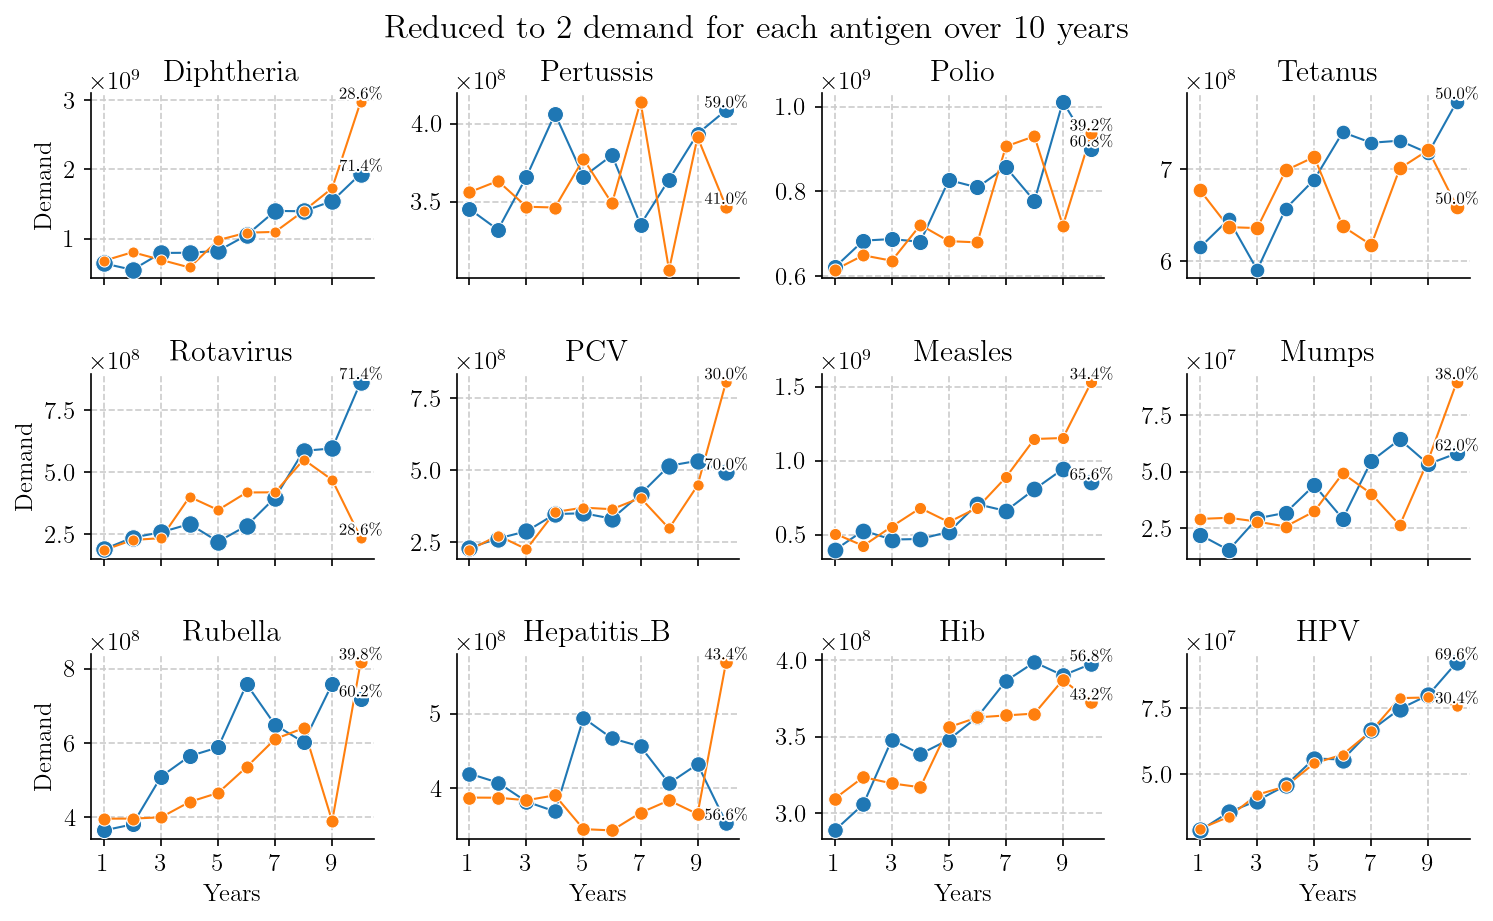

In [19]:
fig, axes = plt.subplots(figsize=(10, 6), ncols=4, nrows=3, sharex=True, sharey=False)
axes = axes.flatten()
for i, antigen in enumerate(ANTIGENS):
    ax = axes[i]
    temp = antigen_reduction_dict[antigen]
    for j, (values, probability) in enumerate(zip(temp["scenarios_Q"], temp["probabilities_Q"])):
        ax.plot(YEARS, values, lw=1, alpha=1, zorder=10)
        ax.scatter(YEARS, values, s=probability * 100, alpha=1, ec="w", lw=0.5, zorder=11)
        # Annotate the probability of each scenario
        ax.annotate(
            f"{probability:.1%}",
            (YEARS[-1], values[-1]),
            ha="center",
            va="bottom",
            zorder=11,
            usetex=False,
            fontsize=8,
            path_effects=[path_effects.withStroke(linewidth=2, foreground="white")],
        )

    ax.set_title(antigen)
    add_grid(ax)

for i in [0, 4, 8]:
    axes[i].set_ylabel("Demand")
for i in [8, 9, 10, 11]:
    axes[i].set_xlabel("Years")
    axes[i].set_xticks(YEARS[::2])

plt.tight_layout()

plt.suptitle(f"Reduced to {Q_SIZE:,} demand for each antigen over 10 years", y=1.02, fontsize=16)
fig.savefig(f"{image_path}/Demand Inputs/all_antigens_demand_reduced.png", dpi=600, bbox_inches="tight")

## Create a portfolio of antigen using roulette wheel random selection

In [20]:
antigen_reduction_dict = joblib.load(f"data/antigen_reduction_dictionary.pkl")

n_master_scenarios = 10  # ! Number of master scenarios to generate

reduced_df = combine_reduced_scenarios(antigen_reduction_dict)
joblib.dump(reduced_df, f"data/combined_reduced_demand_scenarios.pkl")
master_scenarios = create_portfolios(reduced_df, n_master_scenarios, verbose=False)
master_scenarios.to_csv(f"data/{n_master_scenarios}_master_scenarios.csv", index=False)

In [21]:
master_scenarios[master_scenarios["demand_scenario"] == 1]

,antigen,demand,probability,sid,demand_scenario,demand_scenario_probability
0,Diphtheria,"[680265200, 803945300, 692909900, 583199600, 9...",0.286,Diphtheria_S2,1,0.01885
1,HPV,"[28767500, 35606700, 39994900, 45718800, 55903...",0.696,HPV_S1,1,0.01885
2,Hepatitis_B,"[387293200, 387070000, 383680400, 390318900, 3...",0.434,Hepatitis_B_S2,1,0.01885
3,Hib,"[309530000, 323541600, 319441500, 316935000, 3...",0.432,Hib_S2,1,0.01885
4,Measles,"[507630600, 425029300, 555256200, 679938800, 5...",0.344,Measles_S2,1,0.01885
5,Mumps,"[21979100, 15215300, 29282400, 31749200, 43976...",0.620,Mumps_S1,1,0.01885
6,PCV,"[222818500, 273508300, 226052500, 355039200, 3...",0.300,PCV_S2,1,0.01885
7,Pertussis,"[345246800, 331895400, 365913300, 406433000, 3...",0.590,Pertussis_S1,1,0.01885
8,Polio,"[615102200, 649397700, 636547600, 721012500, 6...",0.392,Polio_S2,1,0.01885
9,Rotavirus,"[188002000, 234730800, 256513500, 289735000, 2...",0.714,Rotavirus_S1,1,0.01885


In [22]:
master_scenarios[master_scenarios["demand_scenario"] == 2]

,antigen,demand,probability,sid,demand_scenario,demand_scenario_probability
12,Diphtheria,"[641443900, 549169300, 792984600, 795763700, 8...",0.714,Diphtheria_S1,2,0.18301
13,HPV,"[28767500, 35606700, 39994900, 45718800, 55903...",0.696,HPV_S1,2,0.18301
14,Hepatitis_B,"[387293200, 387070000, 383680400, 390318900, 3...",0.434,Hepatitis_B_S2,2,0.18301
15,Hib,"[288767400, 305847000, 347994400, 338611400, 3...",0.568,Hib_S1,2,0.18301
16,Measles,"[395961400, 527936500, 467295000, 471221900, 5...",0.656,Measles_S1,2,0.18301
17,Mumps,"[21979100, 15215300, 29282400, 31749200, 43976...",0.620,Mumps_S1,2,0.18301
18,PCV,"[222818500, 273508300, 226052500, 355039200, 3...",0.300,PCV_S2,2,0.18301
19,Pertussis,"[345246800, 331895400, 365913300, 406433000, 3...",0.590,Pertussis_S1,2,0.18301
20,Polio,"[620988200, 684057200, 687742900, 681173500, 8...",0.608,Polio_S1,2,0.18301
21,Rotavirus,"[188002000, 234730800, 256513500, 289735000, 2...",0.714,Rotavirus_S1,2,0.18301


### Visualize the portfolio

In [5]:
fig = go.Figure(layout=dict(template="ggplot2", font=dict(family="CMU Serif", size=12, color="black"), hovermode="x unified"))
symbols = ["circle", "square", "diamond", "cross", "x", "triangle-up", "triangle-down", "triangle-left", "triangle-right", "pentagon"]
# Create a mapping of antigens to marker symbols
antigen_to_symbol = {antigen: symbols[i % len(symbols)] for i, antigen in enumerate(ANTIGENS)}

for portfolio, portfolio_data in master_scenarios.groupby("portfolio"):
    for _, data in portfolio_data.iterrows():
        fig.add_trace(
            go.Scatter(
                x=YEARS,
                y=data["demand"],
                mode="lines+markers",
                name=f"P{portfolio}: {data["index"]}",
                line=dict(width=2, color=d3_colors[portfolio % 10]),
                marker=dict(size=7, symbol=antigen_to_symbol[data["index"]], line=dict(width=1, color="black")),
                visible=True if portfolio == 1 else "legendonly",   
                legendgroup=portfolio, opacity=0.8,
            )
        )
fig.update_layout(
    xaxis_title="Years",
    yaxis_title="Demand",
    title=f"{n_master_scenarios} Master Scenarios",
    margin=dict(l=50, r=10, b=50, t=50, pad=0)
)
fig.show()
fig.write_image(f"{image_path}/Demand Inputs/{n_master_scenarios}_master_scenarios.png", scale=5)
fig.write_html(f"{image_path}/Demand Inputs/{n_master_scenarios}_master_scenarios.html")

In [29]:
14 % 10

4

---

# Testing

## Generating the random data


In [15]:
polio_df = pd.read_excel(
    f"{Github_path}/DATA/demand/antigen_CI_Random_generator.xlsx", sheet_name="Polio", nrows=N_YEARS
)
polio_df.index += 1
polio_demand_df = generate_time_series(
    polio_df, 500, mu_col="Average", std_col="sd", lower_col="Lower", upper_col="Upper"
)
polio_demand_df.sample()

,1,2,3,4,5,6,7,8,9,10,sid,prob
332,6.594943e+08,6.092858e+08,6.439769e+08,8.585831e+08,7.605088e+08,8.987463e+08,1.119905e+09,1.030153e+09,7.697187e+08,9.563387e+08,333,0.002


## Scenario reduction for random scenario generation


In [4]:
# Covert the year columns to one columns with list of values
polio_demand_df["demands"] = polio_demand_df[YEARS].values.tolist()
original_demand_dict = polio_demand_df.set_index("sid")["demands"].to_dict()

scenarios_P = polio_demand_df[YEARS].to_numpy()
probabilities_P = polio_demand_df["prob"].to_numpy()

FFS = Fast_Forward_Selection(polio_demand_df, "demands", verbose_level=0)
ffs_set, ffs_probs, ffs_s_dict = FFS.run(Q_SIZE)
ffs_df = FFS.construct_reduced_df()
scenarios_Q = np.array(ffs_df["demands"].tolist())
probabilities_Q = ffs_df["prob"].to_numpy()
metric_abs, metric_rel = get_zeta_metric(
    scenarios_P, scenarios_Q, probabilities_P, probabilities_Q, verbose=False
)  # type: ignore

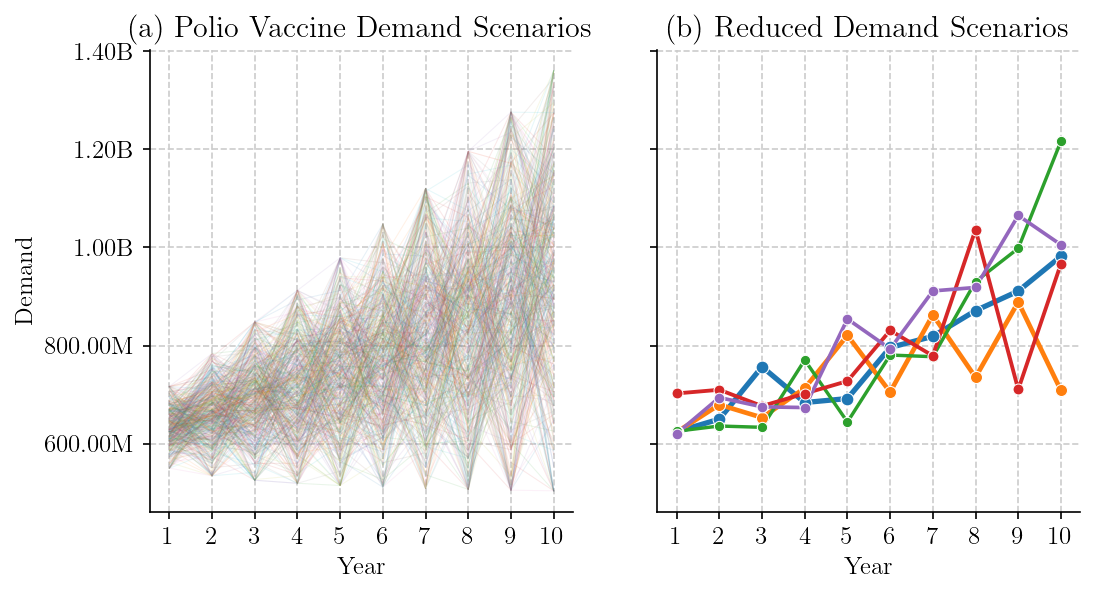

In [7]:
fig, axes = plt.subplots(figsize=(8, 4), ncols=2, sharey=True)

ax = axes[0]
for idx, row in polio_demand_df.iterrows():
    ax.plot(YEARS, row[YEARS], label=f"Scenario {row['sid']}", lw=0.5, alpha=0.1)

ax.set_xlabel("Year")
ax.set_ylabel("Demand")
ax.set_title("(a) Polio Vaccine Demand Scenarios")
ax.set_xticks(YEARS)
add_grid(ax, human_readable=True)

ax = axes[1]
for idx, row in ffs_df.iterrows():
    ax.plot(YEARS, row[YEARS], label=f"Scenario {row['sid']}", lw=row["prob"] * 10, alpha=1)
    ax.scatter(
        YEARS,
        row[YEARS],
        s=row["prob"] * 150,
        alpha=1,
        ec="w",
        lw=0.5,
        zorder=10,
    )
ax.set_title("(b) Reduced Demand Scenarios")
ax.set_xticks(YEARS)
ax.set_xlabel("Year")
add_grid(ax, human_readable=True)
fig.savefig(f"{image_path}/Demand Inputs/polio_demand_scenarios.png", dpi=600, bbox_inches="tight")

NameError: name 'ffs_df' is not defined

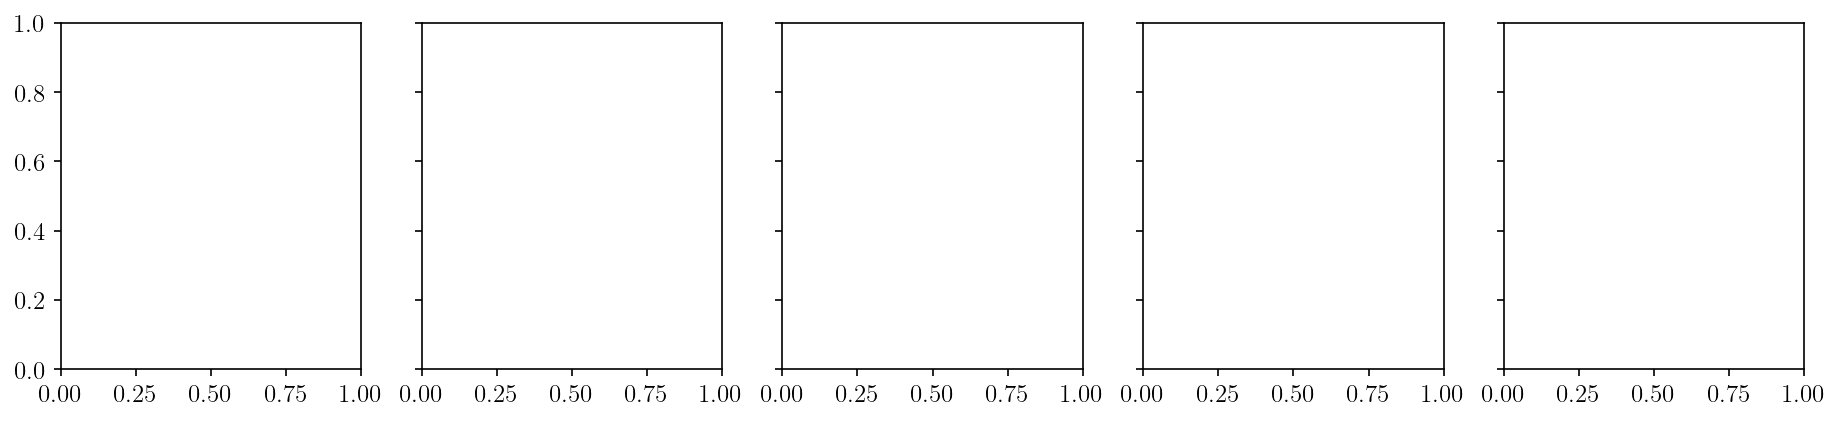

In [4]:
fig, axes = plt.subplots(figsize=(Q_SIZE * 3, 3), nrows=1, ncols=Q_SIZE, sharey=True, sharex=True)

for col_idx, (idx, row) in enumerate(ffs_df.iterrows()):
    ax = axes[col_idx]
    ax.set_title(f"Scenario {row['sid']}")
    ax.plot(YEARS, row[YEARS], label=f"Scenario {row['sid']}", lw=2, alpha=1, color="crimson", zorder=9)
    ax.scatter(
        YEARS,
        row[YEARS],
        s=30,
        c="crimson",
        alpha=1,
        ec="w",
        lw=0.5,
        zorder=10,
    )
    ax.annotate(
        f"Prob: {row['prob']:.2f}",
        (YEARS[-1], row[YEARS[-1]]),
        ha="center",
        va="bottom",
        zorder=11,
        path_effects=[path_effects.withStroke(linewidth=2, foreground="white")],
    )
    for mid in row["merged_sids"]["sid"]:
        ax.plot(YEARS, original_demand_dict[mid], lw=0.5, alpha=0.2, color="gray", zorder=1)

    add_grid(ax, human_readable=True)
    ax.set_xlabel("Year")
    ax.set_xticks(YEARS)


axes[0].set_ylabel("Demand")
fig.savefig(f"{image_path}/Demand Inputs/polio_demand_scenarios_merged.png", dpi=600, bbox_inches="tight")

---

# Scenario tree with 3 possible outcomes


In [ ]:
L, M, H = 0.25, 0.5, 0.75